# Midterm Project (Team 2) — Adidas vs Nike Sneakers


- Franck Kolontchang
- Dylan Legault


Step(s) and the member who completes the step(s).


**Dataset:** `sneakers.csv`

---

## Step 1: Introduction

**Context:**
This project compares Adidas and Nike sneaker products using the provided dataset. We analyze several key features to understand patterns in the sneaker dataset. These include Product Name and Product ID for identifying items, as well as Listing Price and Sale Price to study pricing behavior. We also evaluate Discount levels, Ratings, and Reviews to measure customer perception and product performance. Additionally, we compare Brand differences to observe how companies vary in pricing, popularity, and customer satisfaction.
**Objectives:**
- Perform data and opinion mining from the dataset.
- Answer the mining questions provided in the template.

dataset: sneakers.csv
Features; 8 columns


Data Description

dataset: sneakers.csv

- Product Name: Name of the product
- Product ID: ID of the product
- Listing Price: Listed price of the product
- Sale Price: Sale price of the product
- Discount: Percentage of discount on the product
- Brand: Brand of the product
- Rating: Rating of the product
- Reviews: Number of reviews for the product

## Step 2: Importing Libraries
Import all needed libraries for this project.

In [1]:
# Libraries important to computations
import numpy as np
import pandas as pd
import math
import os
# Visualisation labraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Step 3: Loading the Dataset
Load 'sneakers.csv' and show basic preview.

In [2]:
# Load dataset
df = pd.read_csv("C:\\Users\\madua\\Downloads\\sneakers.csv")
df.head()

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,3.3,24
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,2.6,37
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,4.1,35
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,3.5,72


In [3]:
# create a copy of the Dataset for backup and further analysis
sneakers =df.copy()

In [4]:
# Let's view the first 5 rows of the dataset
sneakers.head()

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,3.3,24
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,2.6,37
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,4.1,35
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,3.5,72


In [5]:
# Let's view the last 5 rows of the dataset
sneakers.tail()

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
3263,Air Jordan 8 Retro,CI1236-100,15995,12797,0,Nike,5.0,1
3264,Nike Phantom Venom Club IC,AO0578-717,4995,3497,0,Nike,0.0,0
3265,Nike Mercurial Superfly 7 Academy TF,AT7978-414,8495,5947,0,Nike,5.0,1
3266,Nike Air Max 98,AH6799-300,0,16995,0,Nike,4.0,4
3267,Nike P-6000 SE,CJ9585-600,8995,6297,0,Nike,0.0,0


## Step 4: EDA Exploratory Data Analysis
### A) Basic Data Exploration

In [6]:
# Total numbers of rows vs colums
# Returns a tuple representing the dimensionality of the DataFrame.
sneakers.shape


(3268, 8)

In [7]:
# Size is the number of rows x number of columns.
# Returns the number of elements in the DataFrame.
sneakers.size

26144

In [8]:
# column names
# This will give us the list of all column names in the DataFrame
# It helps us understand the structure of the dataset
sneakers.columns

Index(['Product Name', 'Product ID', 'Listing Price', 'Sale Price', 'Discount',
       'Brand', 'Rating', 'Reviews'],
      dtype='object')

In [9]:
# number of dimensions
# Returns the number of dimensions of the DataFrame.
sneakers.ndim

2

In [10]:
# Let's determine the data type of each feature
# it helps us understand the possible operations we can perform on each column
sneakers.dtypes

Product Name      object
Product ID        object
Listing Price      int64
Sale Price         int64
Discount           int64
Brand             object
Rating           float64
Reviews            int64
dtype: object

In [11]:
# Shows a summary of the entire DataFrame
# This includes the indexes, a list of the columns, datatypes, non-null values and memory usage
sneakers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   3268 non-null   object 
 1   Product ID     3268 non-null   object 
 2   Listing Price  3268 non-null   int64  
 3   Sale Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Rating         3268 non-null   float64
 7   Reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


In [12]:
# Statistical summary (for only numeric variables)
# This method Checks every cell in the DataFrame and returns True if it's value is missing and False if it’s not.
sneakers.isnull()

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
3263,False,False,False,False,False,False,False,False
3264,False,False,False,False,False,False,False,False
3265,False,False,False,False,False,False,False,False
3266,False,False,False,False,False,False,False,False


In [13]:
# Checking the missing value
# This will give us the count of missing values in each column
# the .sum() method adds up the number of "True" values (missing values) for each column
sneakers.isnull().sum()

Product Name     0
Product ID       0
Listing Price    0
Sale Price       0
Discount         0
Brand            0
Rating           0
Reviews          0
dtype: int64

In [14]:
# Statistical summary (for only numeric variables)
# This give a quick overview of the central tendency (mean, median, mode), dispersion (Range, variance, standard deviation) and shape of a dataset’s distribution, excluding NaN or (Not a Number) values.
sneakers.describe()

,Listing Price,Sale Price,Discount,Rating,Reviews
count,3268.000000,3268.000000,3268.000000,3268.000000,3268.000000
mean,6868.020196,6134.265606,26.875765,3.242105,40.551714
std,4724.659386,4293.247581,22.633487,1.428856,31.543491
min,0.000000,449.000000,0.000000,0.000000,0.000000
25%,4299.000000,2999.000000,0.000000,2.600000,10.000000
50%,5999.000000,4799.000000,40.000000,3.500000,37.000000
75%,8999.000000,7995.000000,50.000000,4.400000,68.000000
max,29999.000000,36500.000000,60.000000,5.000000,223.000000


In [15]:
# include='object' to get summary statistics for categorical columns
# Categorical columns are those that contain discrete values, such as names, labels, or categories.
sneakers.describe(include='object')

,Product Name,Product ID,Brand
count,3268,3268,3268
unique,1531,3179,5
top,Women's adidas Originals Sambarose Shoes,CD6720-808,Adidas CORE / NEO
freq,16,3,1111


In [16]:
# Checks each row and returns True if that row is a duplicate of a previous row.
# This helps us identify duplicate entries in the dataset.
sneakers.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3263    False
3264     True
3265     True
3266    False
3267    False
Length: 3268, dtype: bool

In [17]:
# .sum() function will give us the total number of duplicate rows in the DataFrame
sneakers.duplicated().sum()

88

In [18]:
# This returns the number of times "0" appears in the 'Listing Price' column
df['Listing Price'].value_counts()
#df['Listing Price'].value_counts()[0]

Listing Price
0       426
7999    331
5999    214
4999    185
5599    178
       ... 
7895      1
6495      1
4795      1
3995      1
9495      1
Name: count, Length: 78, dtype: int64

In [30]:
# number of sneakers with listing price under 15000
Listing_price_under_15000 = sneakers[sneakers["Listing Price"] < 15000]
# (sneakers["Listing Price"] < 15000).sum()

### B) Univariate, Bivariate, Multivariate Analyses
Examine distributions, skewness, and outliers for numeric variables.

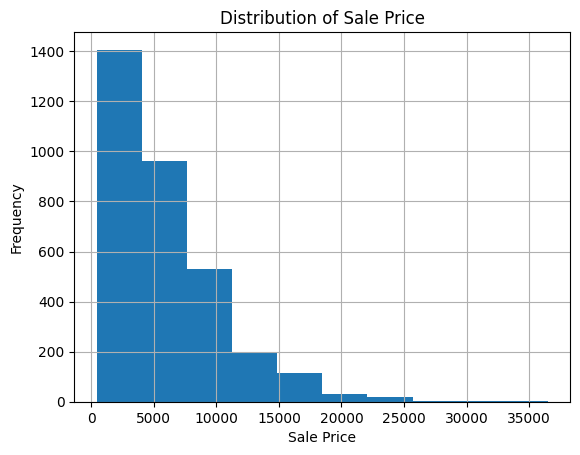

In [52]:
# Univariable Analysis
# This histogram shows the distribution of Sale Prices in the dataset.
# It helps reveal how prices are spread, whether they are low-price heavy,
# and whether the distribution is skewed. Useful for understanding pricing patterns.
plt.hist(sneakers['Sale Price'])
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.grid(True)

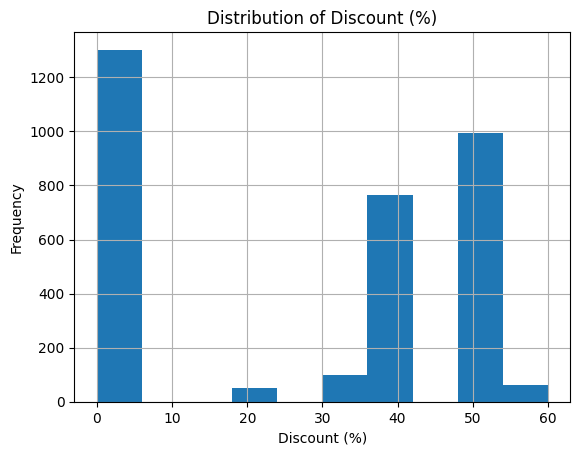

In [53]:
# Univariable Analysis
# This histogram visualizes the percentage discounts offered.
# It helps identify common discount levels and how frequently items are discounted.
plt.hist(sneakers['Discount'])
plt.title("Distribution of Discount (%)")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.grid(True)

In [37]:
sneaker_discount_equal_to_30 = sneakers[sneakers['Discount'] == 30]
print(f"The amount of products with 30% discount is: {sneaker_discount_equal_to_30.shape[0]}")

The amount of products with 30% discount is: 99


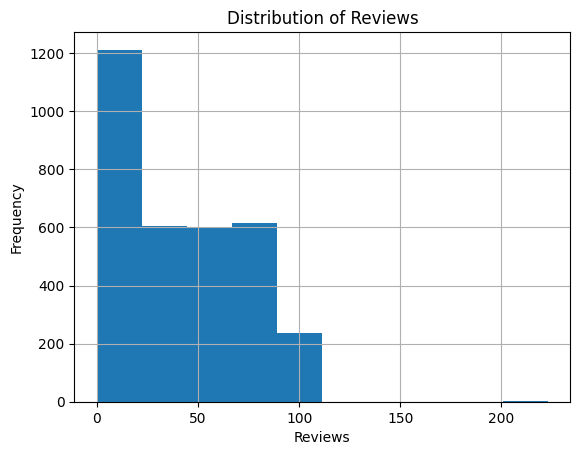

In [54]:
# Univariable Analysis
# This histogram shows the distribution of review counts.
# Many items may have few reviews while a small number have many,
# allowing us to see engagement and popularity levels.
plt.hist(sneakers['Reviews'])
plt.title("Distribution of Reviews")
plt.xlabel("Reviews")
plt.ylabel("Frequency")
plt.grid(True)


In [39]:
# From the histogram above, we see there's some review values way above the normal range
# the statistical summary says the value is 223
# This is to find the number of rows that have exactly 223 reviews
sneakers['Reviews'].value_counts()

Reviews
0      257
1      131
2       87
3       58
5       58
      ... 
99      19
55      15
60      14
223      1
105      1
Name: count, Length: 102, dtype: int64

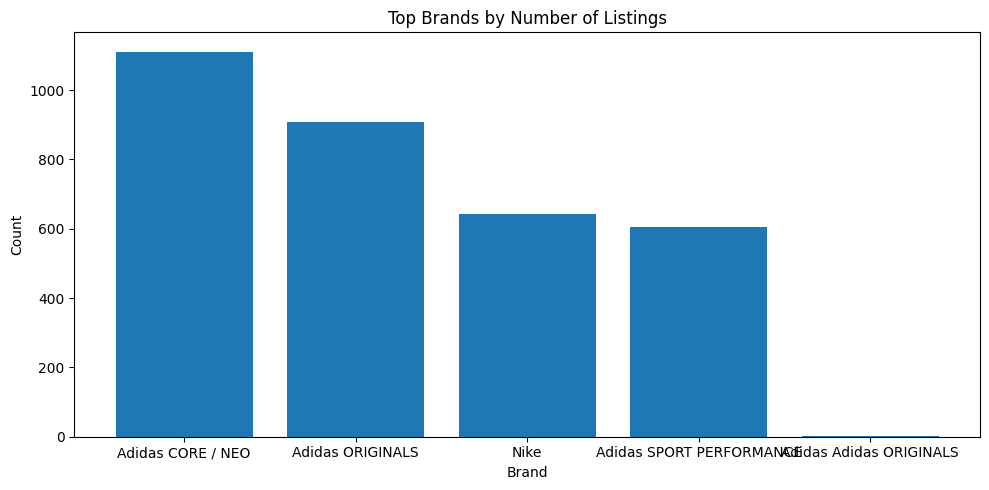

In [56]:
# Univariable Analysis
# This bar chart displays the most common sneaker brands in the dataset.
# It helps identify which brands dominate the dataset and appear most frequently.
top_brands = sneakers['Brand'].value_counts().head(5)
plt.figure(figsize=(10,5))
plt.bar(top_brands.index.astype(str), top_brands.values)
plt.title("Top Brands by Number of Listings")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.tight_layout()

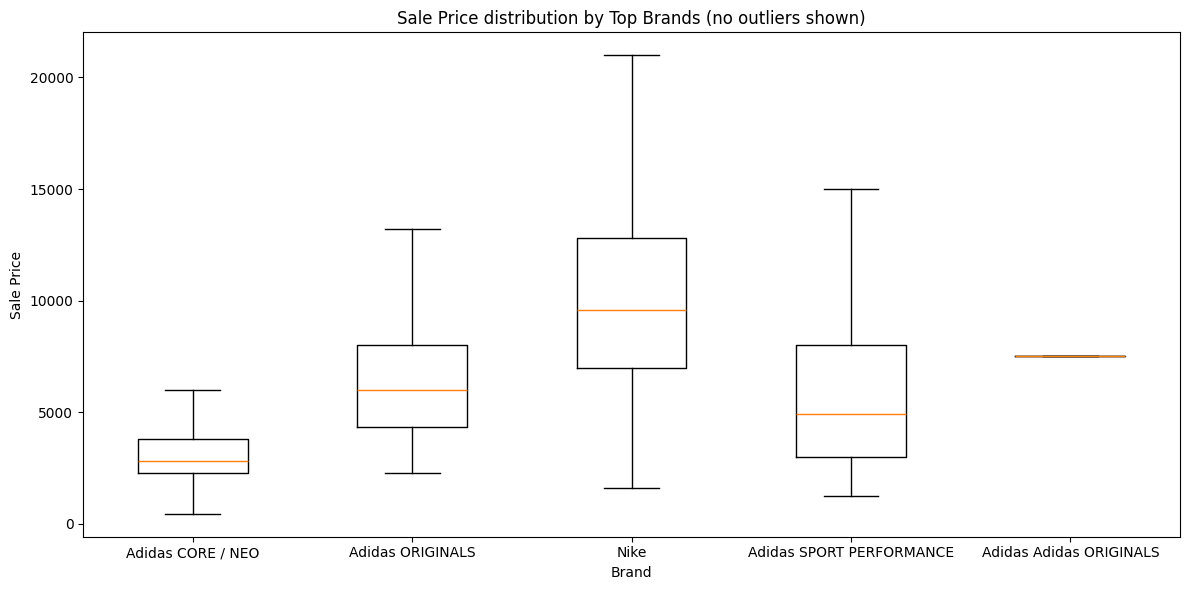

In [44]:
# Univariable Analysis
# This boxplot compares the Sale Price distributions of the top brands.
# It shows median prices, variability, and whether certain brands tend to be more expensive.
top_brand_names = top_brands.index.tolist()
data_for_box = [sneakers.loc[sneakers['Brand']==b, 'Sale Price'].dropna() for b in top_brand_names]

plt.figure(figsize=(12,6))
plt.boxplot(data_for_box, labels=top_brand_names, showfliers=False)
plt.title("Sale Price distribution by Top Brands (no outliers shown)")
plt.xlabel("Brand")
plt.ylabel("Sale Price")
plt.tight_layout()

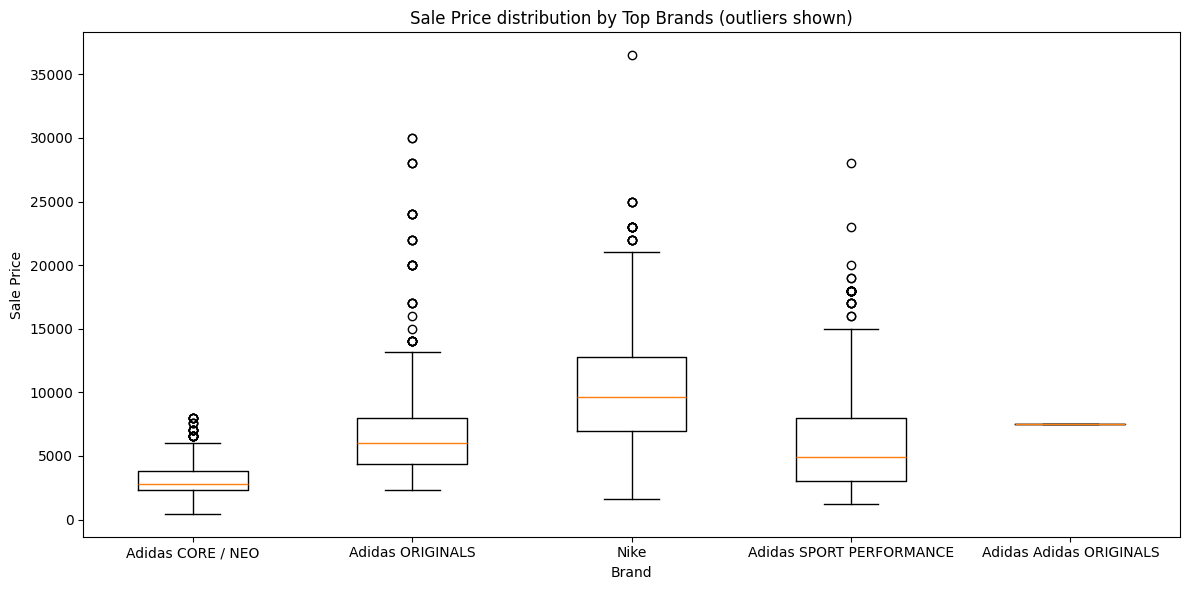

In [45]:
# Univariable Analysis
# This boxplot compares the Sale Price distributions of the top brands.
# It shows median prices, variability, and whether certain brands tend to be more expensive.
top_brand_names = top_brands.index.tolist()
data_for_box = [sneakers.loc[sneakers['Brand']==b, 'Sale Price'].dropna() for b in top_brand_names]

plt.figure(figsize=(12,6))
plt.boxplot(data_for_box, labels=top_brand_names, showfliers=True)
plt.title("Sale Price distribution by Top Brands (outliers shown)")
plt.xlabel("Brand")
plt.ylabel("Sale Price")
plt.tight_layout()

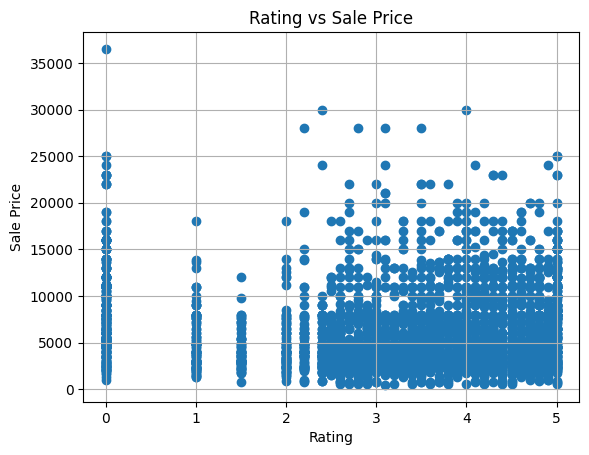

In [51]:
# Bivariable Analysis
# This scatter plot examines the relationship between product Rating and Sale Price.
# It helps determine whether higher-rated items tend to cost more or if rating and price are unrelated.
plt.scatter(sneakers['Rating'], sneakers['Sale Price'])
plt.title("Rating vs Sale Price")
plt.xlabel("Rating")
plt.ylabel("Sale Price")
plt.grid(True)

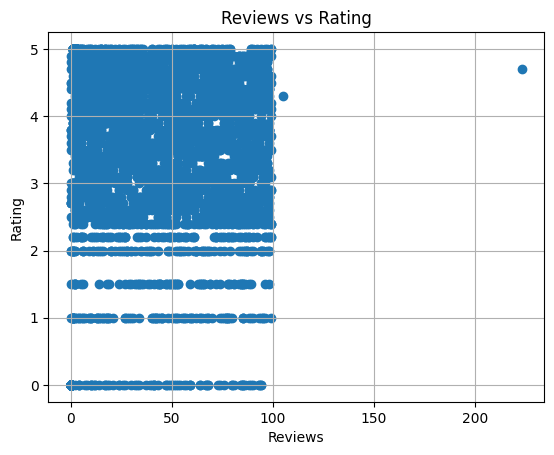

In [50]:
# Bivariable Analysis
# This scatter plot shows the relationship between Reviews and Rating.
# It helps identify whether items with many reviews tend to have higher or lower ratings.
plt.scatter(sneakers['Reviews'], sneakers['Rating'])
plt.title("Reviews vs Rating")
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.grid(True)

In [82]:
# Multivariable Analysis
# Let's create a new df and call it num_col
# num_col would be a DataFrame that contains only the numerical columns from the sneakers dataset

num_col = sneakers[['Listing Price', 'Sale Price', 'Discount', 'Rating', 'Reviews']]
num_col.head()

,Listing Price,Sale Price,Discount,Rating,Reviews
0,14999,7499,50,4.8,41
1,7599,3799,50,3.3,24
2,999,599,40,2.6,37
3,6999,3499,50,4.1,35
4,7999,3999,50,3.5,72


In [83]:
# Multivariable Analysis
# Before creating a heatmap, we need to get the corrrelation table
# the .corr() method computes the pairwise correlation of columns, excluding NA/null values.
# pairwise correlation means that the correlation is calculated for each possible pair of numerical columns in the DataFrame.
num_col.corr()

,Listing Price,Sale Price,Discount,Rating,Reviews
Listing Price,1.000000,0.312255,0.125999,0.099764,0.161296
Sale Price,0.312255,1.000000,-0.594659,-0.042172,-0.240728
Discount,0.125999,-0.594659,1.000000,0.081510,0.313591
Rating,0.099764,-0.042172,0.081510,1.000000,0.140577
Reviews,0.161296,-0.240728,0.313591,0.140577,1.000000


In [146]:
# This is to find how many times Adidas ORIGINALs appears in the Brand column
adidas__adidas_originals_count = sneakers[sneakers['Brand'] == 'Adidas Adidas ORIGINALS'].shape[0]
# adidas_original_count
print(f"The number of times Adidas Adidas ORIGINALS appears in the Brand column: {adidas__adidas_originals_count}")

The number of times Adidas Adidas ORIGINALS appears in the Brand column: 1


## Percentage analysis

In [61]:
# Percentage of products with Listing Price < 15000
total = len(sneakers)
percent_listing_under_15000 = (sneakers['Listing Price'] < 15000).sum() / total * 100
percent_listing_under_15000

94.03304773561811

In [62]:
# Percentage of sneakers with Sale Price under 15000
percent_sale_under_15000 = (sneakers['Sale Price'] < 15000).sum() / total * 100
percent_sale_under_15000


95.65483476132191

In [64]:
# Using value_counts() to show how many products fall into 50% and above discount category
discount_counts = (sneakers['Discount'] >= 50).value_counts()
discount_counts

Discount
False    2213
True     1055
Name: count, dtype: int64

In [68]:
# Percentage of sneakers with at least 50% discount
percent_discount_50 = (sneakers['Discount'] >= 50).sum() / total * 100
percent_discount_50

32.28274173806609

In [69]:
# Percentage of sneakers with ratings less than 3.5 
percentage_under_3_5 = (sneakers['Rating'] < 3.5).sum() / total * 100
percentage_under_3_5

47.24602203182375

In [70]:
# percetage of sneakers with less than 100 reviews
# To show the distribution using value_counts()
reviews_under_100 = (sneakers['Reviews'] < 100).value_counts()
reviews_under_100


Reviews
True     3266
False       2
Name: count, dtype: int64

In [71]:
# For the percentage itself
# To calculate the percentage of sneakers with less than 100 reviews
percentage_reviews_under_100 = (sneakers['Reviews'] < 100).sum() / total * 100
percentage_reviews_under_100

99.93880048959608

In [72]:
sneakers.loc[sneakers['Discount'].idxmax()]

Product Name     Women's adidas Sport Inspired Duramo Lite 2.0 ...
Product ID                                                  B75586
Listing Price                                                 4799
Sale Price                                                    1920
Discount                                                        60
Brand                                            Adidas CORE / NEO
Rating                                                         1.0
Reviews                                                         45
Name: 5, dtype: object

In [73]:
sneakers[sneakers['Discount'] == sneakers['Discount'].max()]

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
5,Women's adidas Sport Inspired Duramo Lite 2.0 ...,B75586,4799,1920,60,Adidas CORE / NEO,1.0,45
59,Men's adidas Running Nayo 1.0 shoes,CI9914,4999,2000,60,Adidas CORE / NEO,3.8,98
154,Women's adidas ORIGINALS SUPERSTAR BOUNCE PK L...,S82260,11999,4800,60,Adidas ORIGINALS,3.5,51
279,Women's adidas ORIGINALS EQT RACING Low Shoes,BB2344,9999,4000,60,Adidas ORIGINALS,3.9,34
368,WOMEN'S ADIDAS SPORT INSPIRED RUN 70S SHOES,B96563,6599,2640,60,Adidas CORE / NEO,2.8,16
...,...,...,...,...,...,...,...,...
2423,Men's adidas ORIGINALS ACTION SPORTS VARIAL Mi...,BY4061,7999,3200,60,Adidas ORIGINALS,2.4,50
2448,men's ADIDAS ORIGINALS ZX FLUX PK SHOES,BA7376,14999,6000,60,Adidas ORIGINALS,3.4,63
2449,MEN'S ADIDAS ORIGINALS EQT SUPPORT MID ADV PRI...,B37435,12999,5200,60,Adidas ORIGINALS,4.3,49
2475,MEN'S ADIDAS SPORT INSPIRED CAFLAIRE SHOES,DB1347,5599,2240,60,Adidas CORE / NEO,3.0,2


In [75]:
# Let's sort the discount column in descending order and drop duplicates
top_discounts = sneakers['Discount'].sort_values(ascending=False).drop_duplicates()

# Highest discount
first_highest = top_discounts.iloc[0]
#first_highest

# Second highest discount
second_highest = top_discounts.iloc[1]
#second_highest

# Third highest discount
third_highest = top_discounts.iloc[2]
first_highest, second_highest, third_highest

(60, 50, 40)

In [ ]:
# Let's count how many times each discount value appears
discount_counts = sneakers['Discount'].value_counts()

# Convert to percentages
discount_percentages = (discount_counts / len(sneakers)) * 100
discount_percentages
# Get the 3 most occurring percentages
# top_3_discount_percentages = discount_percentages.head(3)
# top_3_discount_percentages

Discount
0     39.840881
50    30.416157
40    23.347613
30     3.029376
60     1.866585
20     1.499388
Name: count, dtype: float64

In [77]:
# Let's find the top 10 products with the highest ratings
top10_rated = sneakers.sort_values(by='Rating', ascending=False).head(10)
top10_product_names = top10_rated['Product Name']
top10_product_names


2899                      Nike Air Max 270 SE
275        Women's adidas Swim Eezay Slippers
2875       Nike SB Zoom Stefan Janoski Mid RM
267         Men's adidas Toe Side II Slippers
3189                          Nike Air Max 97
3193            Nike Phantom Venom Academy TF
2608    Men's adidas Tennis Gumption II Shoes
3075                          Nike Air Max 90
2885                 Jordan Trunner NXT React
3074                     Nike Shox TL Nova SP
Name: Product Name, dtype: object

In [78]:
# Lets find the top 10 products with the highest number of reviews
top10_reviewed = sneakers.sort_values(by='Reviews', ascending=False).head(10)
top10_reviewd_names = top10_reviewed['Product Name']
top10_reviewd_names

2750                           Air Jordan 10 Retro
2805                                 Nike Zoom Fly
560          Men's adidas Outdoor Geocach 19 Shoes
1997      Men's adidas Running Ultraboost 19 Shoes
1568               Men's Originals Drop Step Shoes
425      Men's adidas Sport Inspired Run 60s Shoes
667       Men's adidas RUNNING Stardrift Low Shoes
2166     Men's adidas Originals Forest Grove Shoes
492     Women's adidias Originals Supercourt Shoes
1274                 Men's Running Nova Flow Shoes
Name: Product Name, dtype: object

In [79]:
# Let's calculate who gives a more discount on average, Nike or Adidas

nike_avg_discount = sneakers[sneakers['Brand'] == 'Nike']['Discount'].mean()
adidas_avg_discount = sneakers[sneakers['Brand'] == 'Adidas']['Discount'].mean()
nike_avg_discount, adidas_avg_discount

(0.0, nan)

### C) Visualization
Correlation heatmap and pairplot (numeric variables).

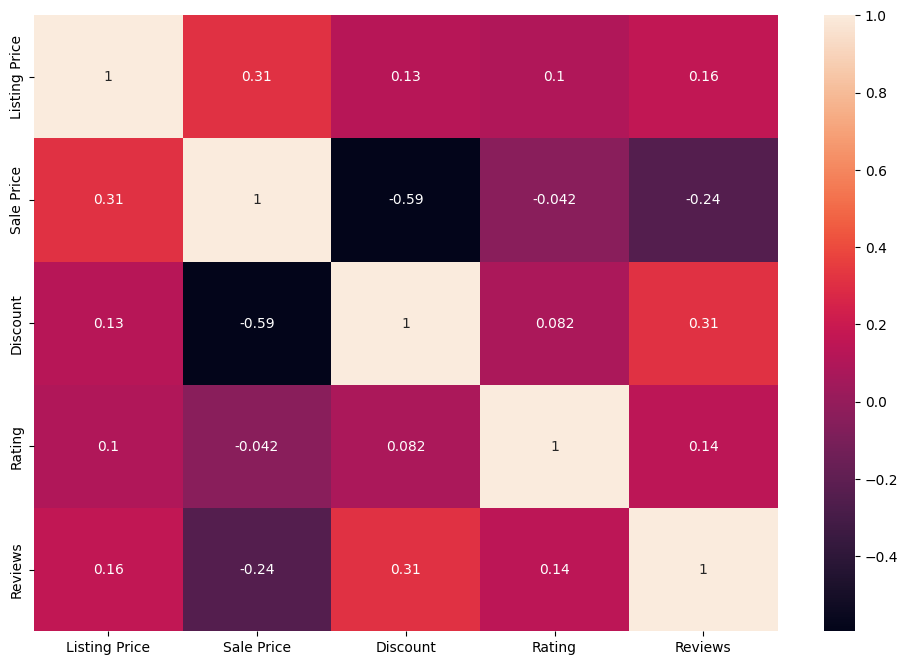

In [84]:
# Now we can create the heatmap to visualise the correlation table
# A heatmap is a graphical representation of data where individual values are represented as colors.
plt.figure(figsize= (12,8))
sns.heatmap(num_col.corr(), annot=True); #semicolon or no semi colon

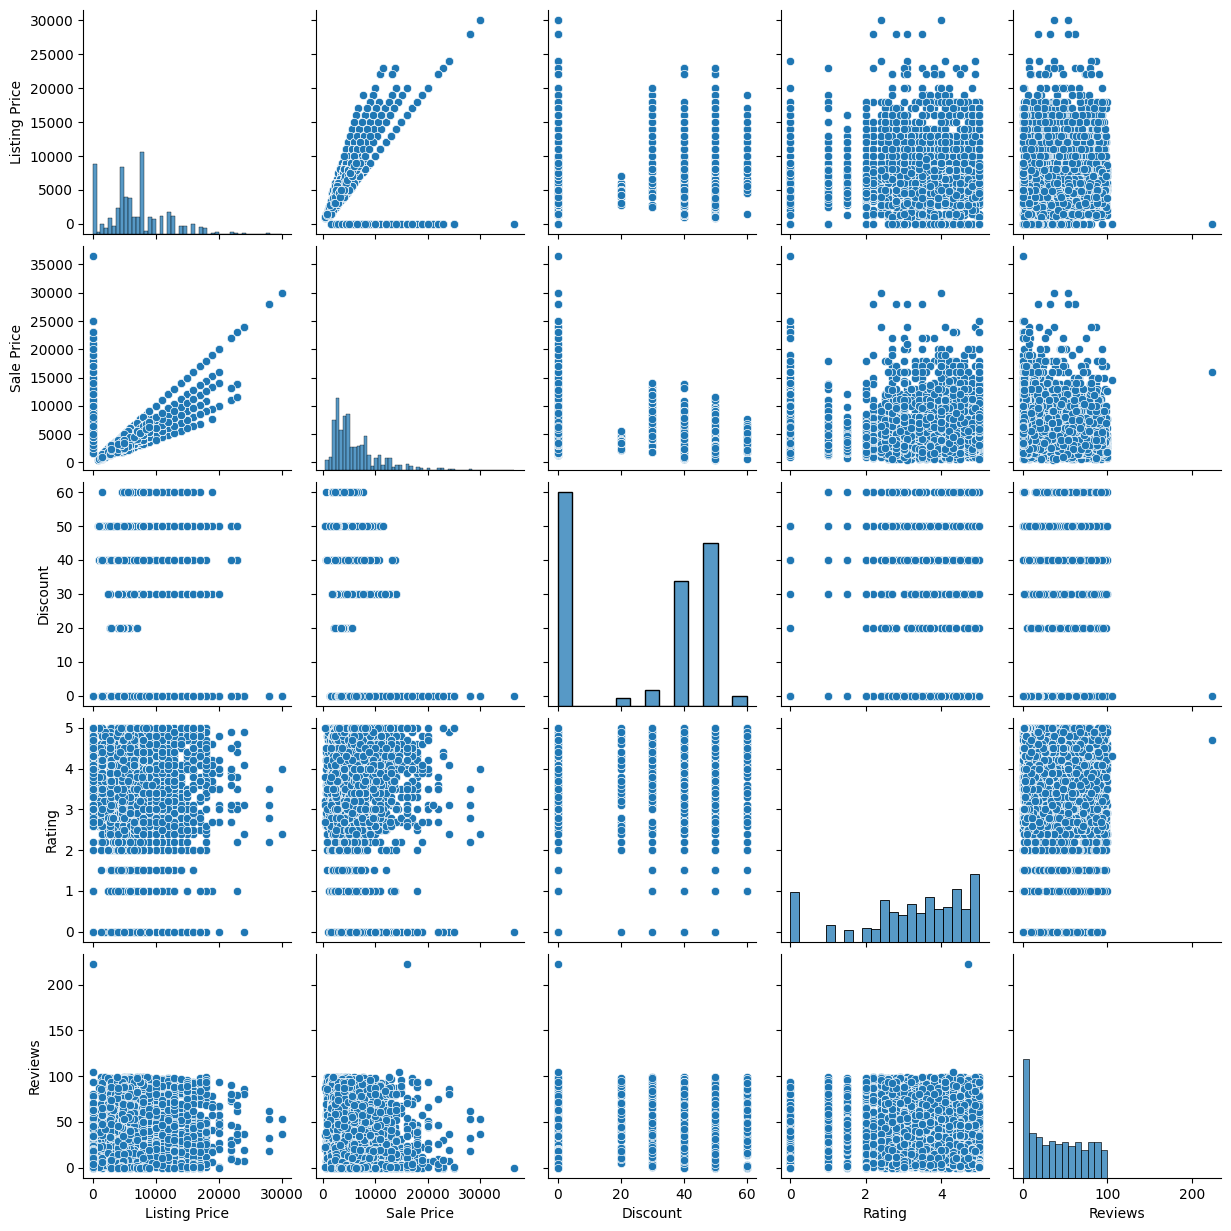

In [85]:
# Now, let's create a pairplot to visualise relationships between multiple variables
sns.pairplot(sneakers, vars=['Listing Price', 'Sale Price', 'Discount', 'Rating', 'Reviews']); # semicolon or no semicolon

### D) EDA Summary
Summarize key observations from the EDA below.

**EDA Summary (short):**

- Add observations about distributions, presence of zero listing prices, skewed columns, correlations between price and rating, and brand differences.
- This section should be filled after inspecting the plots above.

* The dataset is clean, with no missing values in any column.
* All columns have expected data types (strings for categories, numeric for prices).
* The sale price distribution is heavily right-skewed.
* The reviews distribution is also right-skewed.
* Most sneakers fall into a mid-price range, with a small number of extremely high-priced sneakers stretching the distribution.
* Brands like Nike and Adidas dominate the dataset.
* We noticed the "Adidas Adidas ORIGINAL" brand rarely appeared, showing the dataset isn’t evenly distributed across brands.

## Step 5: Answering the Mining Questions
Below are the mining questions and computed answers.

**Mining Questions:**
Answer all questions here (after each question).
1. What is the shape of the dataset?
Ans- The shape of the dataset is (3268,8)
2. Are there any missing values in this dataset?
Ans- This dataset is pristine in that aspect, there is no missing data in this dataset.
3. List all 8 columns' dtypes.
Poduct Name, Prduct ID, Listing price, Sale price, Discount, Brand, Rating, Reviews.
4. Are there any duplicated rows (observations) in this dataset?
Ans- There are 88 duplicated rows.
5. **Refer to the statistical summary of the dataset and answer the following:**
 - The average listing price: The average listing price is "6868.020196"
 - The average sale price: The average sale price is "6134.265606"
 - The average discount: The average discount is "26.875765%"
 - The average rating: The average rating is a "3.242105"
 - The average number of reviews: The average number of reviews is "40.551714"
6. Which "Brand" has the highest number of products in this dataset?
Ans- The Adidas CORE / NEO has the highest number of products in this dataset.
7. As you can see, the "Listing Price" for some products is zero (0). How many products with zero listing price are there in this dataset?
Ans- "0" appears 426 times in the Listing price column.
8. **Perform the "Univariate EDA", and examine any type of skewness (outliers) for all the variables.**
Ans- The distributions of sale price and reviews are both heavily right skewed. The right skew of the sale price means most of the values are low to moderate. Most sneakers fall in the affordable range, especially with the discounts, while a few like luxury or limited editions may cost higher. Concerning the reviews, it's sort of the same thing. Most products have few reviews and a only small number have a lot of reviews.
9. **The the percentage for the following:**
 - Products with listing prices less than 15000: 94.03%
 - Products with sale price less than 15000: 95.65%
 - Products with at least 50% discount: 32.28%
 - Products with rating less than 3.5: 47.25%
 - Products with review numbers less than 100: 99.94%
 - The 3 highest percentages of the discount graph: 60%. 50% and 40%
10. **Perform the "Bivariate EDA", and examine the following:**
- The two highly positively correlated variables: Discount and Reviews.
- The two highly negatively correlated variables: Discount and Sale Price
11. What are the names of the 10 highest rated products? 
Ans: 
- Nike Air Max 270 SE
- Women's adidas Swim Eezay Slippers
- Nike SB Zoom Stefan Janoski Mid RM
- Men's adidas Toe Side II Slippers
- Nike Air Max 97
- Nike Phantom Venom Academy TF
- Men's adidas Tennis Gumption II Shoes
- Nike Air Max 90
- Jordan Trunner NXT React
- Nike Shox TL Nova SP
12. What are the 10 products' names with the highest number of reviews?
Ans: 
- Air Jordan 10 Retro
- Nike Zoom Fly
- Men's adidas Outdoor Geocach 19 Shoes
- Men's adidas Running Ultraboost 19 Shoes
- Men's Originals Drop Step Shoes
- Men's adidas Sport Inspired Run 60s Shoes
- Men's adidas RUNNING Stardrift Low Shoes
- Men's adidas Originals Forest Grove Shoes
- Women's adidias Originals Supercourt Shoes
- Men's Running Nova Flow Shoes
13. which company gives more discount: Adidas or Nike?
Ans- Adidas gives more discount.

## Step 6: Conclusion

**Ten Insights gained and observed:**

1. This dataset informs us about the performance of foot wear brands brands. Their reviews, ratings and overall customer satisfaction.
2. It's been interesting to see that the dataset has no missing values.
3. As for relationships, The strongest positive correlation is between Discount and Reviews. This is because the more the discount, the more people would buy, so there will be more reviews.
4. The Listing price and Sale price also have high positive correlation. This is because a high listing price is generally associated with a high sale price
5. The strongest negative correlation here is between Sale Price and Discount. Thsi makes sense because The more the discount, the lower the sale price.
6. Some of the Listing Price values are "0". Our best guess is that these are data entry errors.
7. The "Review" variable has an outlier. One product has 223 reviews while the second highest has just a little over 100. This comes from the "Air Jordan 10 Retro". It happens to be a very popular shoe.
8. The dataset contains both integer, float and object variable datatypes
9. The Nike Air Max 270 SE has the highest rating of all the products.
10. This dataset would be useful for Brands to optimize ther marketing and sales and build better relationships with customers.
11. An important observation of ours is that the "Adidas Adidas ORIGINALS brand appeared only once.